id: 236
query: Where would the second image’s observer appear in the first image? Answer with image-plane coordinates (X, Y) and depth in meters. Choose the correct answer from the choices available.
question_type: None
candidates: ['Image Coor:(888, 29), Depth:2.9 meters', 'Image Coor:(857, 70), Depth:2.9 meters', 'Image Coor:(239, 248), Depth:2.9 meters', 'Image Coor:(977, 4), Depth:2.9 meters']
target: Image Coor:(239, 248), Depth:2.9 meters
pred: Image Coor:(239, 248), Depth:2.9 meters  correct: True  sim_score: None


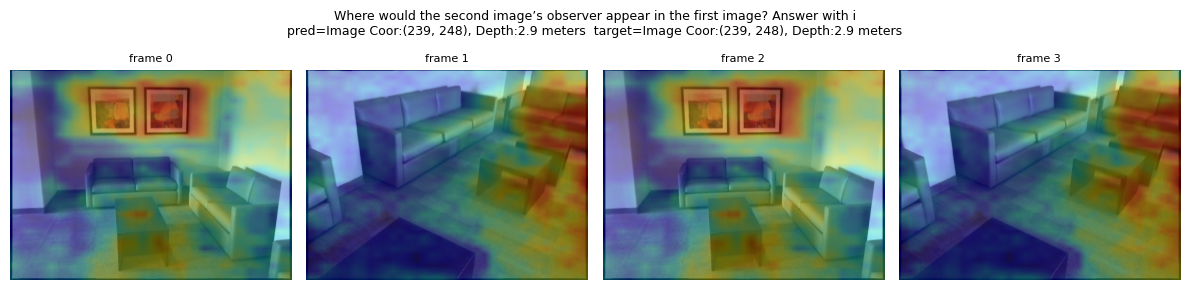

In [11]:
import json, random
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

output_dir = Path("../outputs/inference/spar_sanity_check_test")  # 换成你实际output_dir
pred_path = output_dir / "vsibench_predictions.jsonl"

rows = [json.loads(l) for l in open(pred_path)]
row = random.choice(rows)   # 或者按条件挑: next(r for r in rows if r["id"]=="xxx")

print(f"id: {row['id']}")
print(f"query: {row['query']}")
print(f"question_type: {row['question_type']}")
print(f"candidates: {row['candidates']}")
print(f"target: {row['target']}")
print(f"pred: {row['pred']}  correct: {row['correct']}  sim_score: {row['sim_score']}")

if row["grounding_path"] is not None:
    g_dir = output_dir / row["grounding_path"]
    heatmap = np.load(g_dir / "heatmap.npy")          # (S, 37, 37)
    overlay_paths = sorted(g_dir.glob("overlay_*.jpg"), key=lambda p: int(p.stem.split("_")[1]))

    n = len(overlay_paths)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for k, p in enumerate(overlay_paths):
        axes[k].imshow(Image.open(p))
        axes[k].set_title(f"frame {k}", fontsize=8)
        axes[k].axis("off")
    fig.suptitle(f"{row['query'][:80]}\npred={row['pred']}  target={row['target']}", fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print("no grounding saved for this row (save_grounding=false or --no-grounding)")